# Programação Linear

Módulo extra, fora da trilha principal Estatística → Econometria — Pesquisa Operacional
trata de **decisão ótima**: dado um objetivo (maximizar lucro, minimizar custo) e
restrições de recursos, qual a melhor decisão possível? Programação Linear (PL) é o caso
em que o objetivo e as restrições são todos lineares.

Pré-requisito: [Módulo 00 — Python Essencial](../00_Python_Essencial)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog
import pulp

plt.rcParams.update({'font.size': 12})

def fmt_brl(valor):
    """Formata número no padrão brasileiro: ponto como milhar, vírgula como decimal."""
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

## 1. Formulando um problema de Programação Linear

### Exemplo — mix de produção

Uma fábrica produz dois produtos, com lucro unitário de R\$ 40 (produto 1) e R\$ 30
(produto 2). Cada unidade consome recursos de dois processos:

| Recurso | Produto 1 | Produto 2 | Disponibilidade |
|---|---|---|---|
| Mão de obra (h) | 1 | 1 | 40 |
| Matéria-prima (kg) | 2 | 1 | 60 |

Quanto produzir de cada item para **maximizar o lucro**?

$$\max 40x_1 + 30x_2 \quad \text{s.a.} \quad x_1+x_2 \leq 40,\ \ 2x_1+x_2 \leq 60,\ \ x_1,x_2 \geq 0$$

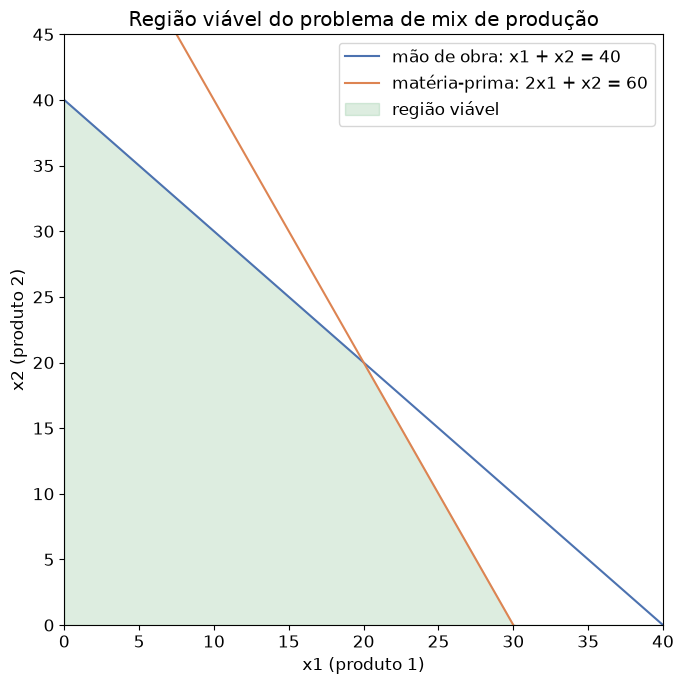

In [2]:
fig, ax = plt.subplots(figsize=(7, 7))
x1 = np.linspace(0, 40, 200)

# Restrição de mão de obra: x1 + x2 <= 40  ->  x2 <= 40 - x1
ax.plot(x1, 40 - x1, label='mão de obra: x1 + x2 = 40', color='#4C72B0')
# Restrição de matéria-prima: 2x1 + x2 <= 60  ->  x2 <= 60 - 2x1
ax.plot(x1, 60 - 2*x1, label='matéria-prima: 2x1 + x2 = 60', color='#DD8452')

# Região viável = interseção das duas restrições (e dos eixos)
x2_viavel = np.minimum(40 - x1, 60 - 2*x1)
x2_viavel = np.clip(x2_viavel, 0, None)
ax.fill_between(x1, 0, x2_viavel, alpha=0.2, color='#55A868', label='região viável')

ax.set_xlim(0, 40); ax.set_ylim(0, 45)
ax.set_xlabel('x1 (produto 1)'); ax.set_ylabel('x2 (produto 2)')
ax.set_title('Região viável do problema de mix de produção')
ax.legend()
plt.tight_layout()
plt.savefig('img_regiao_viavel.png', dpi=110)
plt.show()

A solução ótima de um problema de PL está sempre em um **vértice** da região viável
(um resultado fundamental da teoria de otimização linear) — é exatamente essa
propriedade que o método Simplex explora.

## 2. Resolvendo com `scipy.optimize.linprog`

`linprog` só resolve problemas de **minimização** — para maximizar, basta minimizar o
negativo da função objetivo.

In [3]:
# Maximizar 40x1 + 30x2  <=>  Minimizar -40x1 - 30x2
c = [-40, -30]

A_ub = [[1, 1],    # mão de obra
        [2, 1]]    # matéria-prima
b_ub = [40, 60]

resultado = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=[(0, None), (0, None)], method='highs')

x1_otimo, x2_otimo = resultado.x
lucro_maximo = -resultado.fun

print(f"x1 (produto 1) = {x1_otimo:.1f} unidades")
print(f"x2 (produto 2) = {x2_otimo:.1f} unidades")
print(f"Lucro máximo = {fmt_brl(lucro_maximo)}")

x1 (produto 1) = 20.0 unidades
x2 (produto 2) = 20.0 unidades
Lucro máximo = R$ 1.400,00


## 3. Preços-sombra (variáveis duais)

Além da solução ótima, o problema **dual** responde: quanto valeria, em lucro adicional,
**uma unidade a mais** de cada recurso escasso? Essa é a leitura econômica do
preço-sombra — informação valiosa para decidir se vale a pena contratar mais horas de
mão de obra ou comprar mais matéria-prima.

In [4]:
precos_sombra = -resultado.ineqlin.marginals  # sinal invertido por convenção do solver

print(f"Preço-sombra da mão de obra:     {fmt_brl(precos_sombra[0])} por hora adicional")
print(f"Preço-sombra da matéria-prima:   {fmt_brl(precos_sombra[1])} por kg adicional")
print("\nOs dois recursos estão totalmente utilizados na solução ótima (restrições ativas)")
print("-- por isso ambos têm preço-sombra positivo: relaxar qualquer um dos dois aumentaria o lucro.")

Preço-sombra da mão de obra:     R$ 20,00 por hora adicional
Preço-sombra da matéria-prima:   R$ 10,00 por kg adicional

Os dois recursos estão totalmente utilizados na solução ótima (restrições ativas)
-- por isso ambos têm preço-sombra positivo: relaxar qualquer um dos dois aumentaria o lucro.


## 4. O método Simplex

O Simplex (Dantzig, 1947) resolve PL percorrendo os **vértices** da região viável,
sempre se movendo para um vértice vizinho que melhora a função objetivo, até não haver
mais melhoria possível — muito mais eficiente do que testar todos os vértices um a um.
O solver padrão do `linprog` (`HiGHS`) usa uma implementação de simplex dual/primal (e
métodos de ponto interior) muito mais robusta e rápida que uma implementação didática,
mas o princípio geométrico é o mesmo: a solução ótima está garantidamente em um vértice,
e o algoritmo pula de vértice em vértice sem precisar visitar todos.

## 5. Formulando o mesmo problema com PuLP

`scipy.optimize.linprog` exige montar matrizes; `PuLP` permite escrever o modelo quase
como no papel -- mais legível para problemas maiores.

In [5]:
problema = pulp.LpProblem('mix_producao', pulp.LpMaximize)

x1_pulp = pulp.LpVariable('x1', lowBound=0)
x2_pulp = pulp.LpVariable('x2', lowBound=0)

problema += 40 * x1_pulp + 30 * x2_pulp, 'lucro'
problema += x1_pulp + x2_pulp <= 40, 'mao_de_obra'
problema += 2 * x1_pulp + x2_pulp <= 60, 'materia_prima'

problema.solve(pulp.PULP_CBC_CMD(msg=0))

print(f"Status: {pulp.LpStatus[problema.status]}")
print(f"x1 = {x1_pulp.varValue}   x2 = {x2_pulp.varValue}")
print(f"Lucro = {fmt_brl(pulp.value(problema.objective))}")

Status: Optimal
x1 = 20.0   x2 = 20.0
Lucro = R$ 1.400,00


## 6. Modelo de transporte

Um caso clássico de PL: minimizar o custo de transportar um produto de **fontes**
(fábricas) para **destinos** (centros de distribuição), respeitando a oferta de cada
fonte e a demanda de cada destino.

### Exemplo — 2 fábricas, 3 centros de distribuição

| | D1 | D2 | D3 | Oferta |
|---|---|---|---|---|
| **F1** | R\$4 | R\$6 | R\$8 | 100 |
| **F2** | R\$5 | R\$4 | R\$3 | 150 |
| **Demanda** | 80 | 90 | 80 | |

In [6]:
oferta = {'F1': 100, 'F2': 150}
demanda = {'D1': 80, 'D2': 90, 'D3': 80}
custo = {
    ('F1', 'D1'): 4, ('F1', 'D2'): 6, ('F1', 'D3'): 8,
    ('F2', 'D1'): 5, ('F2', 'D2'): 4, ('F2', 'D3'): 3,
}

problema_transporte = pulp.LpProblem('transporte', pulp.LpMinimize)
rotas = {(f, d): pulp.LpVariable(f'x_{f}_{d}', lowBound=0) for f in oferta for d in demanda}

problema_transporte += pulp.lpSum(custo[f, d] * rotas[f, d] for f in oferta for d in demanda)

for f in oferta:
    problema_transporte += pulp.lpSum(rotas[f, d] for d in demanda) <= oferta[f], f'oferta_{f}'
for d in demanda:
    problema_transporte += pulp.lpSum(rotas[f, d] for f in oferta) >= demanda[d], f'demanda_{d}'

problema_transporte.solve(pulp.PULP_CBC_CMD(msg=0))

print(f"Status: {pulp.LpStatus[problema_transporte.status]}\n")
for (f, d), var in rotas.items():
    if var.varValue and var.varValue > 0:
        print(f"  {f} -> {d}: {var.varValue:.0f} unidades (custo unitário R$ {custo[f,d]})")
print(f"\nCusto total mínimo: {fmt_brl(pulp.value(problema_transporte.objective))}")

Status: Optimal

  F1 -> D1: 80 unidades (custo unitário R$ 4)
  F1 -> D2: 20 unidades (custo unitário R$ 6)
  F2 -> D2: 70 unidades (custo unitário R$ 4)
  F2 -> D3: 80 unidades (custo unitário R$ 3)

Custo total mínimo: R$ 960,00


## 7. Exercícios de fixação

1. No problema de mix de produção, o que acontece com a solução ótima se o lucro
   unitário do produto 2 subir de R\$ 30 para R\$ 45? Resolva novamente com `linprog`.
2. No modelo de transporte, adicione uma terceira fábrica F3 com oferta de 50 unidades e
   custos de R\$ 6 (D1), R\$ 3 (D2) e R\$ 5 (D3). Resolva novamente com PuLP.

In [7]:
# 1.
c_novo = [-40, -45]
resultado_novo = linprog(c_novo, A_ub=A_ub, b_ub=b_ub, bounds=[(0, None), (0, None)], method='highs')
print(f"1) x1={resultado_novo.x[0]:.1f}  x2={resultado_novo.x[1]:.1f}  lucro={fmt_brl(-resultado_novo.fun)}")
print("   Com produto 2 mais lucrativo, o mix ótimo se desloca para produzir mais dele.")

# 2.
oferta2 = {'F1': 100, 'F2': 150, 'F3': 50}
custo2 = dict(custo)
custo2.update({('F3', 'D1'): 6, ('F3', 'D2'): 3, ('F3', 'D3'): 5})

problema2 = pulp.LpProblem('transporte_2', pulp.LpMinimize)
rotas2 = {(f, d): pulp.LpVariable(f'y_{f}_{d}', lowBound=0) for f in oferta2 for d in demanda}
problema2 += pulp.lpSum(custo2[f, d] * rotas2[f, d] for f in oferta2 for d in demanda)
for f in oferta2:
    problema2 += pulp.lpSum(rotas2[f, d] for d in demanda) <= oferta2[f]
for d in demanda:
    problema2 += pulp.lpSum(rotas2[f, d] for f in oferta2) >= demanda[d]
problema2.solve(pulp.PULP_CBC_CMD(msg=0))
print(f"\n2) Custo total mínimo com F3: {fmt_brl(pulp.value(problema2.objective))}")

1) x1=0.0  x2=40.0  lucro=R$ 1.800,00
   Com produto 2 mais lucrativo, o mix ótimo se desloca para produzir mais dele.

2) Custo total mínimo com F3: R$ 870,00


## Bibliografia
- HILLIER, Frederick S.; LIEBERMAN, Gerald J. *Introdução à Pesquisa Operacional*. 9. ed. Porto Alegre: AMGH, 2013.
- TAHA, Hamdy A. *Pesquisa Operacional*. 8. ed. São Paulo: Pearson, 2008.
- WINSTON, Wayne L. *Operations Research: Applications and Algorithms*. 4. ed. Cengage Learning, 2003.